In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
import shap

In [9]:
df = pd.read_csv('../Dataset/Processed/Merged_Dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.tail()

,Date,Close,High,Low,Open,Volume,Company,DE10YT_Yield,EURUSD_Close,EURUSD_Volume,...,OVX_Close,TTF_Gas_Close,VIX_Close,Gold_Close,EBITDA,Net_Income,ROA,Total_Assets,Total_Debt,Cash
615926,2025-12-19,7.58,7.61,7.54,7.57,53.8,ZIGNAGO VETRO,2.8925,1.1708,40683.0,...,33.62,28.20,14.91,3703.98,NaN,NaN,NaN,NaN,NaN,NaN
615927,2025-12-22,7.63,7.70,7.48,7.57,91.6,ZIGNAGO VETRO,2.9044,1.1760,48571.0,...,33.03,27.77,14.08,3777.43,NaN,NaN,NaN,NaN,NaN,NaN
615928,2025-12-23,7.67,7.75,7.61,7.71,50.4,ZIGNAGO VETRO,2.8647,1.1794,55315.0,...,33.02,27.78,14.00,3800.40,NaN,NaN,NaN,NaN,NaN,NaN
615929,2025-12-29,7.79,7.80,7.63,7.63,78.6,ZIGNAGO VETRO,2.8257,1.1772,50852.0,...,32.16,28.69,14.20,3679.45,NaN,NaN,NaN,NaN,NaN,NaN
615930,2025-12-30,7.77,7.84,7.72,7.82,42.7,ZIGNAGO VETRO,2.8533,1.1746,44821.0,...,30.76,27.80,14.33,3691.29,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
features = [
    'Open', 'High', 'Low', 'Close', 'Volume', 
    'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 
    'Euribor_3M', 'FTMIB_Close', 'FTMIB_Volume', 'GVZ_Close', 
    'IT10YT_Yield', 'IT_Inflation', 'IT_GDP', 'IT_Unemployment', 
    'Brent_Close', 'Brent_Volume', 'OVX_Close', 
    'TTF_Gas_Close', 'VIX_Close', 'Gold_Close'
]

targets = ['EBITDA', 'ROA', 'Net_Income']

# Feature Selection & Target Engineering Pipeline
This section of the study aims to identify the most predictive features (market data and macroeconomic indicators) for forecasting corporate fundamental targets (EBITDA, ROA, Net Income). Because the dataset contains sequential financial data, 90-day lookback windows prior to each financial report release are extracted, calculating the **mean** (Level/Trend) and **standard deviation** (Volatility/Shock)for each feature.

To ensure robust and unbiased feature selection, three distinct mathematical frameworks are employed:

**1. Mutual Information**

Mutual Information (MI) is a non-parametric metric that measures the reduction in uncertainty about the target variable given the knowledge of a specific feature. Unlike traditional Pearson correlation, MI is completely model-agnostic and can capture complex, non-linear relationships between macroeconomic shocks and corporate fundamentals.

**2. Random Forest & Gini Importance**

Random Forest is an ensemble learning method and the feature importance is calculated using the Gini Importance (Mean Decrease in Impurity) metric. 
It calculates how much each feature contributes to reducing the variance (in regression) or impurity (in classification) across all the decision trees in the forest. It provides an excellent measure of the absolute predictive power of a variable.

**3. SHAP Values**

While Random Forest shows how much a feature matters, SHAP (SHapley Additive exPlanations) explains how it matters: it values break down the prediction to show the directional impact of each feature. A SHAP summary plot allows us to visually understand whether a high value of a specific feature pushes the model's prediction higher or lower, providing crucial economic interpretability to our black-box models. Red dots indicate that a high value of the feature increases the probability of an upward trend, while blue dots indicate that a high value decreases it. If the dots are on the right side of the plot, it means that the feature pushes the prediction towards an upward trend; if they are on the left, it means that the feature pushes the prediction towards a downward trend.

## Part 1: Absolute Target Analysis - Regression

In this first analytical phase, the algorithms are tasked with predicting the absolute values of the financial targets. 

This approach serves as a baseline to test the models' behavior on raw, unscaled accounting data. We treat this as a continuous Regression problem using `RandomForestRegressor` and `mutual_info_regression`.


                                EBITDA                                
Total valid 90-day windows extracted: 4446

Top 10 Features by Mutual Information for EBITDA:
           Feature  MI_Score
       Volume_MEAN  0.572950
        Volume_STD  0.437810
EURUSD_Volume_MEAN  0.048162
  Brent_Volume_STD  0.038688
  IT_Inflation_STD  0.036853
  EURUSD_Close_STD  0.028724
 Brent_Volume_MEAN  0.026894
 FTMIB_Volume_MEAN  0.026385
 EURUSD_Volume_STD  0.023816
     GVZ_Close_STD  0.022416


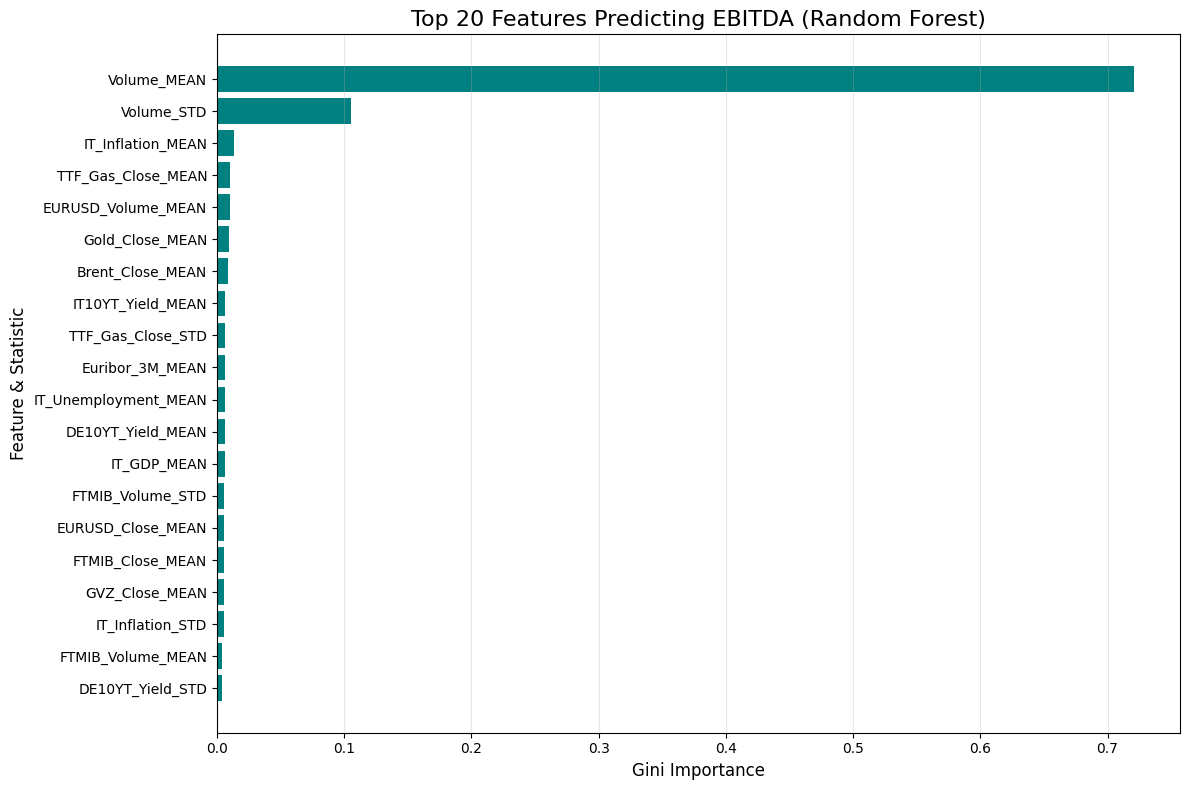

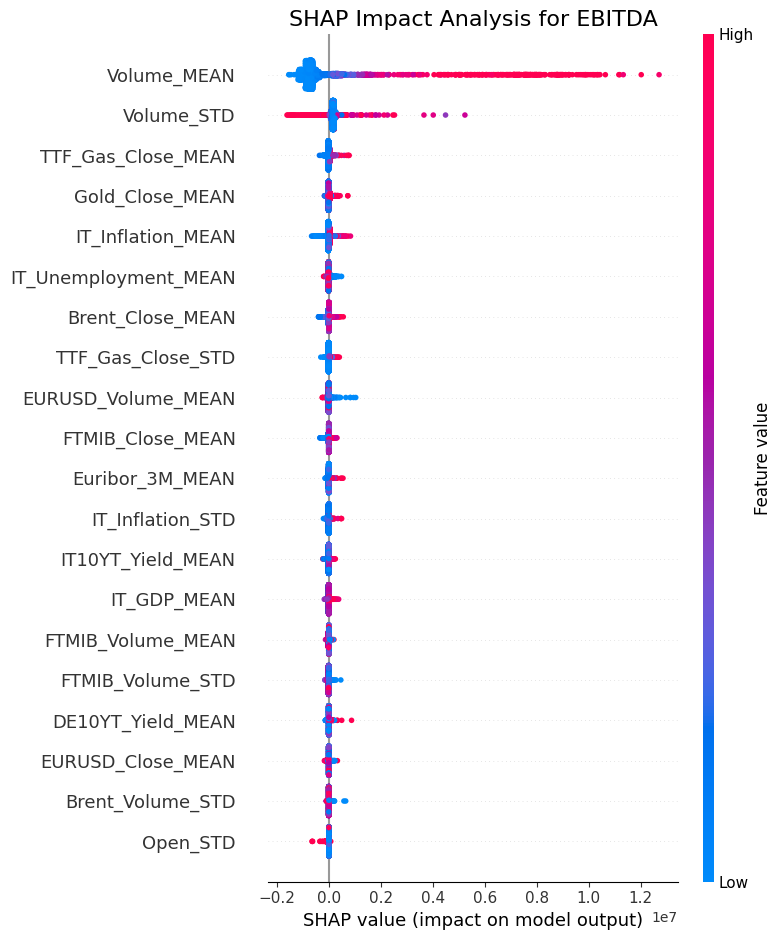


                                 ROA                                  
Total valid 90-day windows extracted: 4500

Top 10 Features by Mutual Information for ROA:
           Feature  MI_Score
       Volume_MEAN  0.201891
        Volume_STD  0.149832
EURUSD_Volume_MEAN  0.017014
  IT_Inflation_STD  0.010302
         High_MEAN  0.008986
        Close_MEAN  0.008985
          Low_MEAN  0.008975
         Open_MEAN  0.008972
   Gold_Close_MEAN  0.008628
     GVZ_Close_STD  0.008257


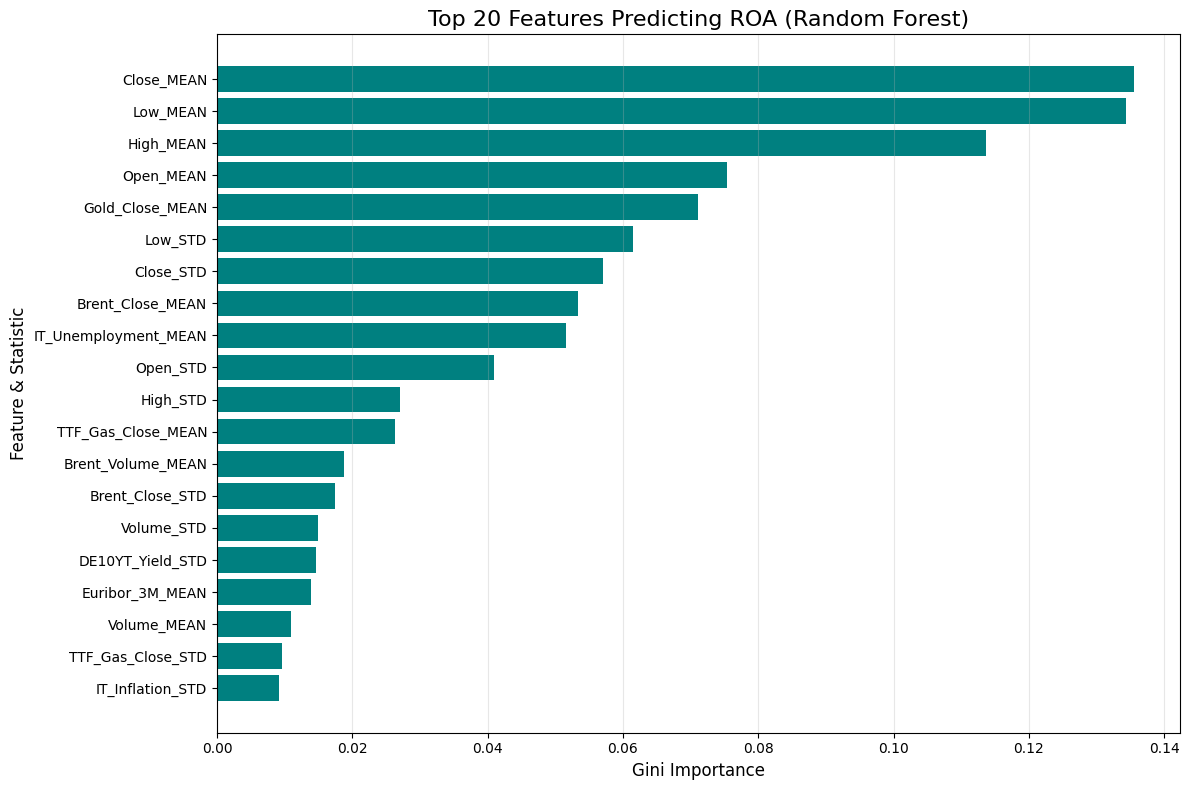

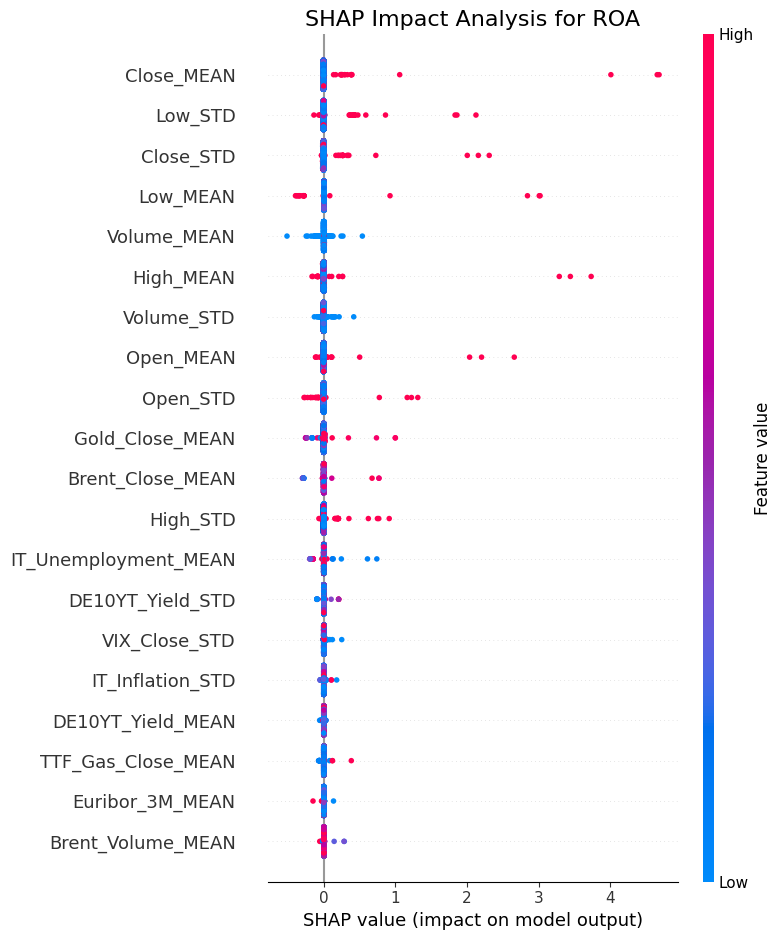


                              Net_Income                              
Total valid 90-day windows extracted: 4503

Top 10 Features by Mutual Information for Net_Income:
           Feature  MI_Score
       Volume_MEAN  0.497448
        Volume_STD  0.350914
EURUSD_Volume_MEAN  0.050664
  Brent_Volume_STD  0.050645
 Brent_Volume_MEAN  0.050352
  IT_Inflation_STD  0.046384
  EURUSD_Close_STD  0.046021
  FTMIB_Volume_STD  0.044853
 EURUSD_Volume_STD  0.041503
  IT10YT_Yield_STD  0.040889


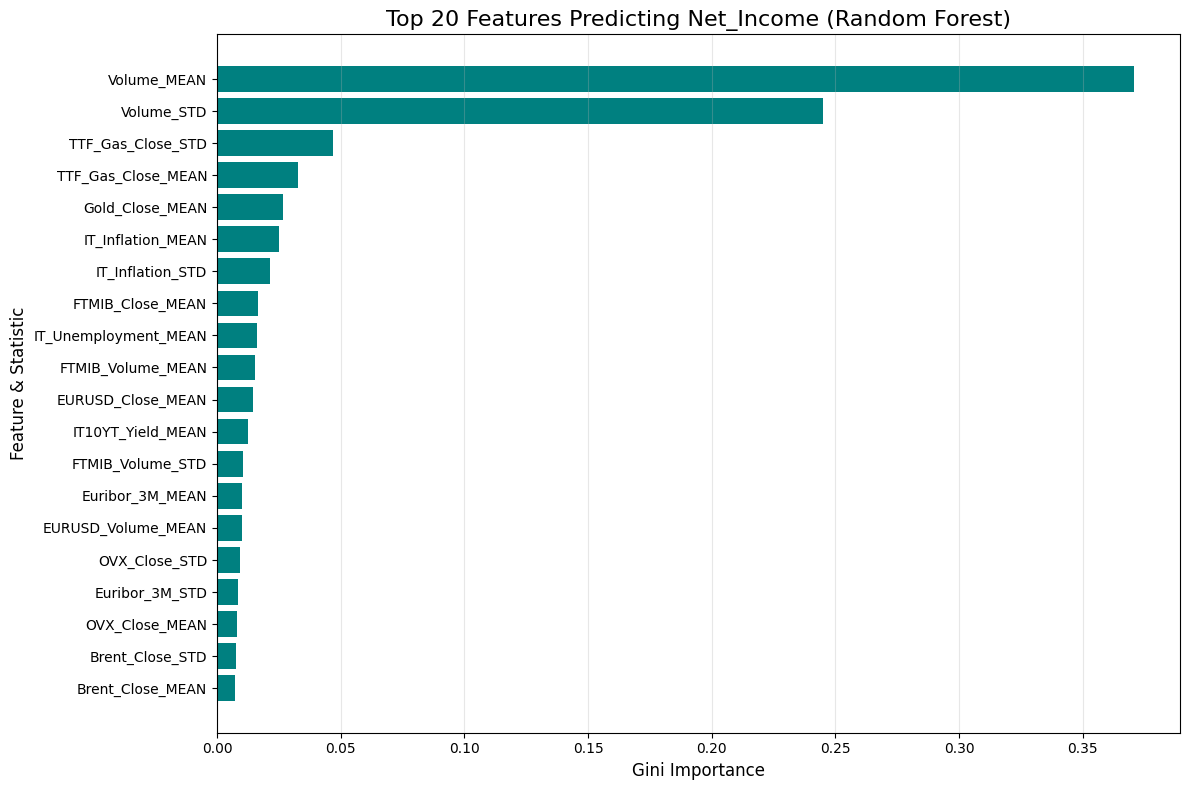

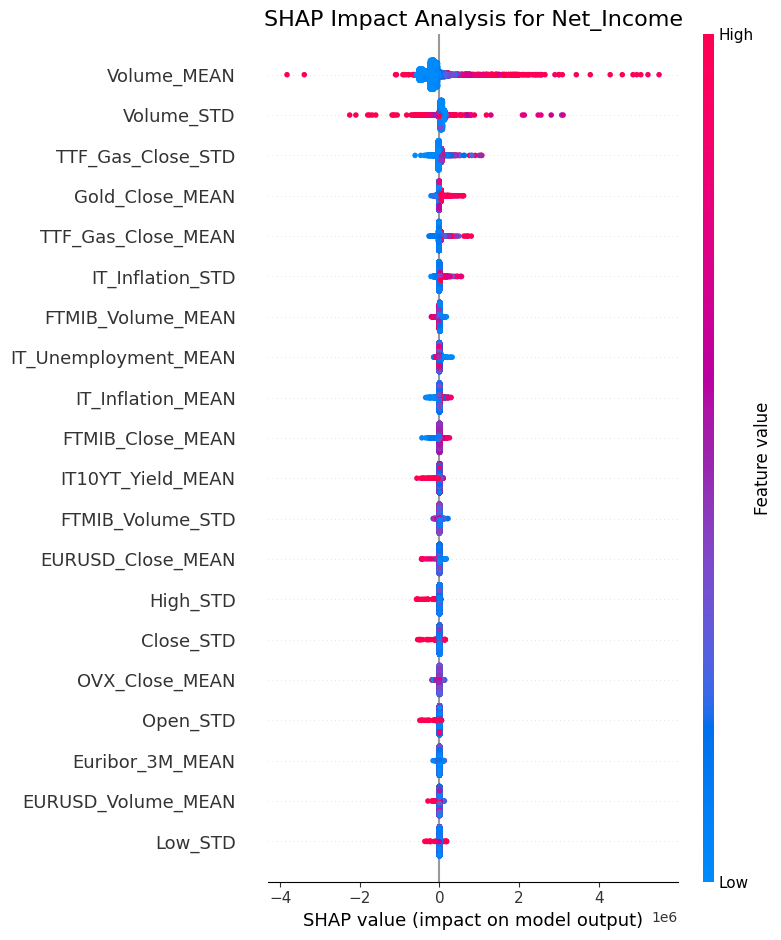

In [11]:
for target in targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []

    target_indices = df[df[target].notna()].index

    for idx in target_indices:
        target_date = df.loc[idx, 'Date']
        company = df.loc[idx, 'Company']
        target_value = df.loc[idx, target]
        
        start_date = target_date - pd.Timedelta(days=90)
        
        window = df[(df['Company'] == company) & 
                    (df['Date'] > start_date) & 
                    (df['Date'] <= target_date)]
        
        if len(window) > 40:
            window_stats = {}
            for feat in features:
                window_stats[f"{feat}_MEAN"] = window[feat].mean()
                window_stats[f"{feat}_STD"] = window[feat].std()
                
            X_aggregated.append(window_stats)
            y_values.append(target_value)

    X_df = pd.DataFrame(X_aggregated).fillna(0)
    y_series = pd.Series(y_values)
    print(f"Total valid 90-day windows extracted: {len(X_df)}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df)
    
    # Mutual Information Regression
    mi_scores = mutual_info_regression(X_scaled, y_series, random_state=42)
    mi_df = pd.DataFrame({
        'Feature': X_df.columns,
        'MI_Score': mi_scores
    }).sort_values(by='MI_Score', ascending=False)
    
    print(f"\nTop 10 Features by Mutual Information for {target}:")
    print(mi_df.head(10).to_string(index=False))

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=6)
    rf.fit(X_scaled, y_series)

    importance_df = pd.DataFrame({
        'Feature': X_df.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    # Plotting random forest
    top_features = importance_df.head(20).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 8))
    plt.barh(top_features['Feature'], top_features['Importance'], color='teal')
    plt.title(f'Top 20 Features Predicting {target} (Random Forest)', fontsize=16)
    plt.xlabel('Gini Importance', fontsize=12)
    plt.ylabel('Feature & Statistic', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    
    rf_save_path = f'../Analysis/Features Importance/Absolute Target/{target}_RF.png'
    plt.savefig(rf_save_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Plotting SHAP values
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Impact Analysis for {target}", fontsize=16)
    
    # show=False prevents SHAP from immediately consuming the plot, allowing us to save it
    shap.summary_plot(shap_values, X_df, plot_type="dot", show=False)
    plt.tight_layout()
    
    shap_save_path = f'../Analysis/Features Importance/Absolute Target/{target}_SHAP.png'
    plt.savefig(shap_save_path, dpi=300, bbox_inches='tight')
    plt.show()

## Part 2: Momentum and Directional Forecasting

The results from Part 1 reveal a critical structural bias in predicting absolute financial variables, commonly known as the "Size Trap". 
For raw targets like EBITDA and Net Income, the models assigned overwhelming importance to trading volumes (`Volume_MEAN` and `Volume_STD`). Because the dataset contains both Small Cap and Large Cap companies, the algorithm stops analyzing financial performance and instead uses Volume as a proxy for Market Capitalization. It essentially learns a basic heuristic: companies with high trading volumes are massive, therefore their EBITDA will be in the billions.

To build a true predictive model that evaluates economic performance rather than company scale, the target variables are changed using two key transformations:
1. **Quarter-over-Quarter (QoQ) Momentum:** Instead of predicting the absolute level of the fundamentals, we calculate the percentage change compared to the previous quarter. A +5% growth is mathematically identical for a multi-national corporation and a local startup, effectively neutralizing the size bias.
2. **Directional Target (Classification):** the QoQ momentum is further refined into a binary target: **1 (Up)** if the fundamental improved, and **0 (Down)** if it worsened. 

By shifting the architecture from Regression to **Binary Classification**, we force the algorithms to ignore the company's size and focus exclusively on the macroeconomic drivers and market signals that dictate economic expansion or contraction.

In [12]:
directional_targets = []

for target in targets:
    df_valid = df.dropna(subset=[target]).copy()
    
    # Calculate Quarter-over-Quarter percentage change
    qoq_col = f"{target}_QoQ_Pct"
    df_valid[qoq_col] = df_valid.groupby('Company')[target].pct_change(1)
    
    # Define Direction: 1 if UP (QoQ > 0), 0 if DOWN or FLAT
    dir_col = f"{target}_Direction_Up"
    df_valid[dir_col] = np.where(df_valid[qoq_col] > 0, 1, 0)
    
    # If QoQ is NaN (first known value of the company), set Direction to NaN
    df_valid.loc[df_valid[qoq_col].isna(), dir_col] = np.nan
    df.loc[df_valid.index, dir_col] = df_valid[dir_col]
    directional_targets.append(dir_col)


                         EBITDA_Direction_Up                          
Total valid 90-day windows extracted for classification: 4397

Top 10 Features by Mutual Information for EBITDA_Direction_Up:
             Feature  MI_Score
     Euribor_3M_MEAN  0.243558
      Euribor_3M_STD  0.241923
   FTMIB_Volume_MEAN  0.241496
       OVX_Close_STD  0.239448
      OVX_Close_MEAN  0.238996
      GVZ_Close_MEAN  0.237318
   IT10YT_Yield_MEAN  0.236895
   DE10YT_Yield_MEAN  0.236643
IT_Unemployment_MEAN  0.235946
      VIX_Close_MEAN  0.235520


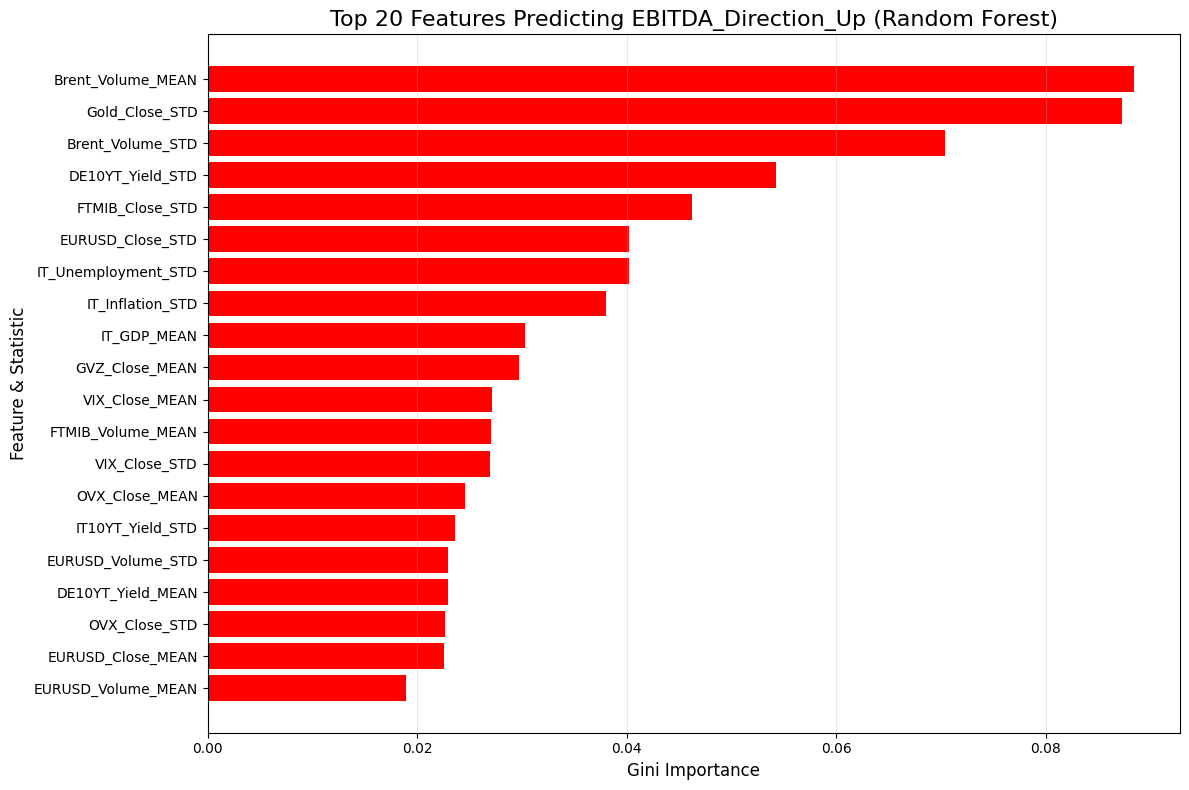

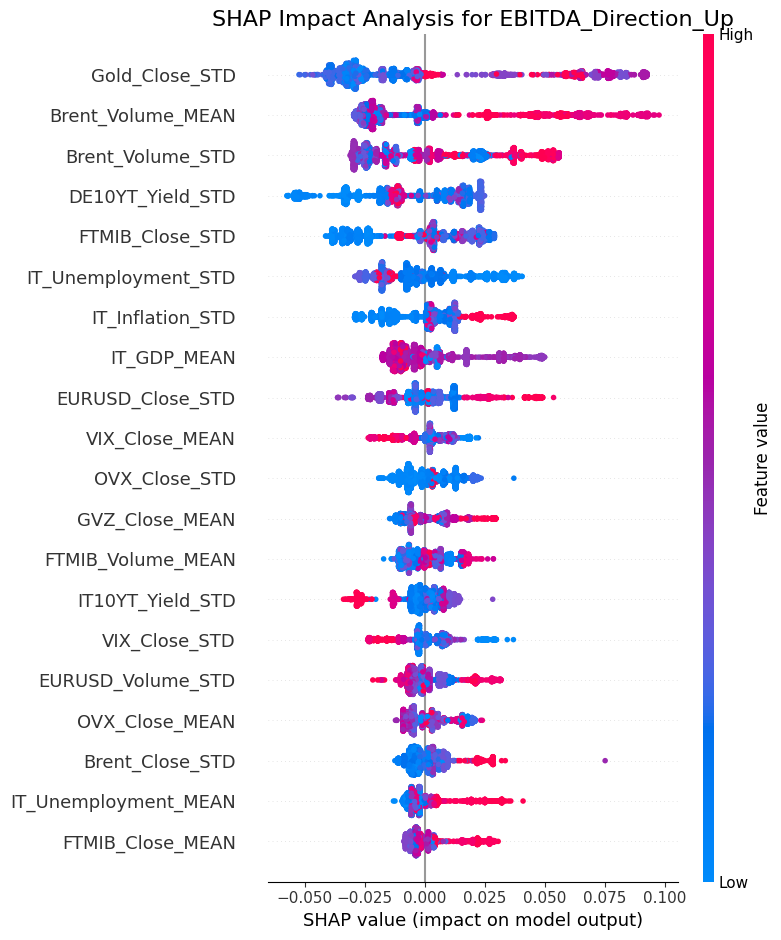


                           ROA_Direction_Up                           
Total valid 90-day windows extracted for classification: 4456

Top 10 Features by Mutual Information for ROA_Direction_Up:
             Feature  MI_Score
    FTMIB_Close_MEAN  0.168742
       VIX_Close_STD  0.165030
  TTF_Gas_Close_MEAN  0.163195
      OVX_Close_MEAN  0.162146
      GVZ_Close_MEAN  0.161653
IT_Unemployment_MEAN  0.160430
     Euribor_3M_MEAN  0.158602
   IT_Inflation_MEAN  0.157703
   Brent_Volume_MEAN  0.157488
     Gold_Close_MEAN  0.157473


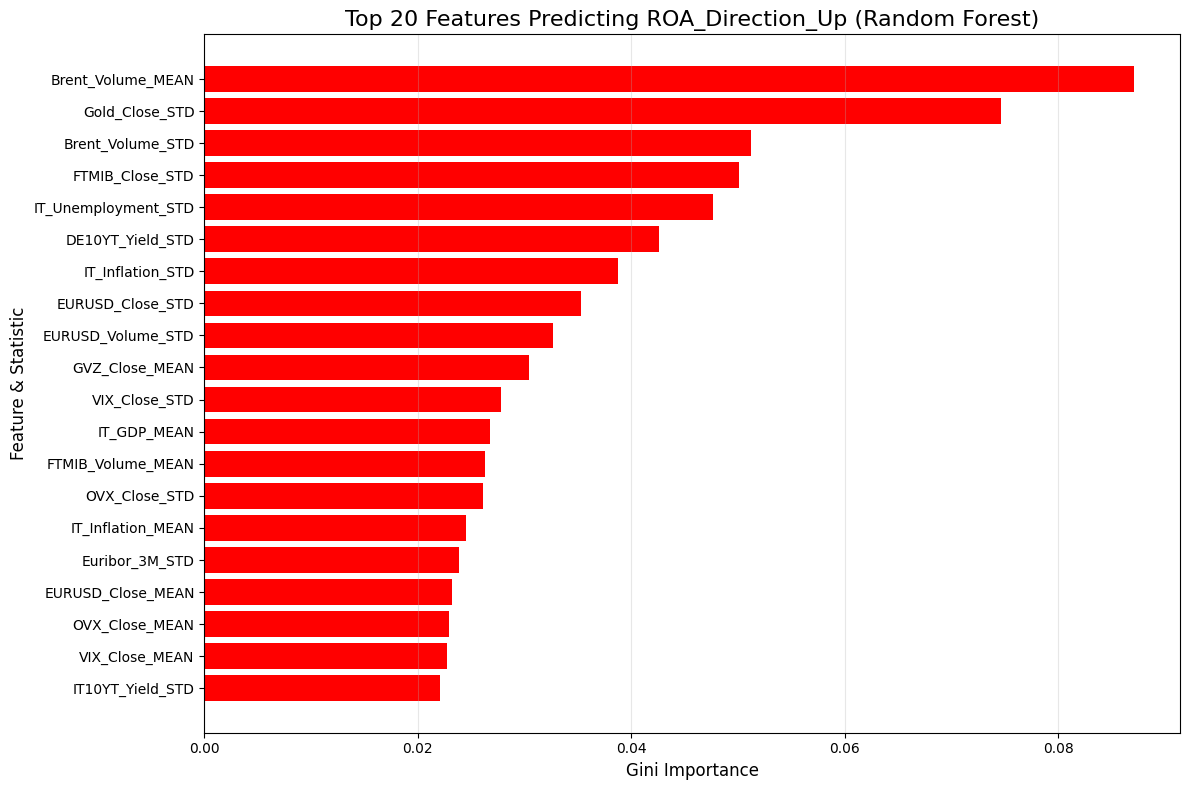

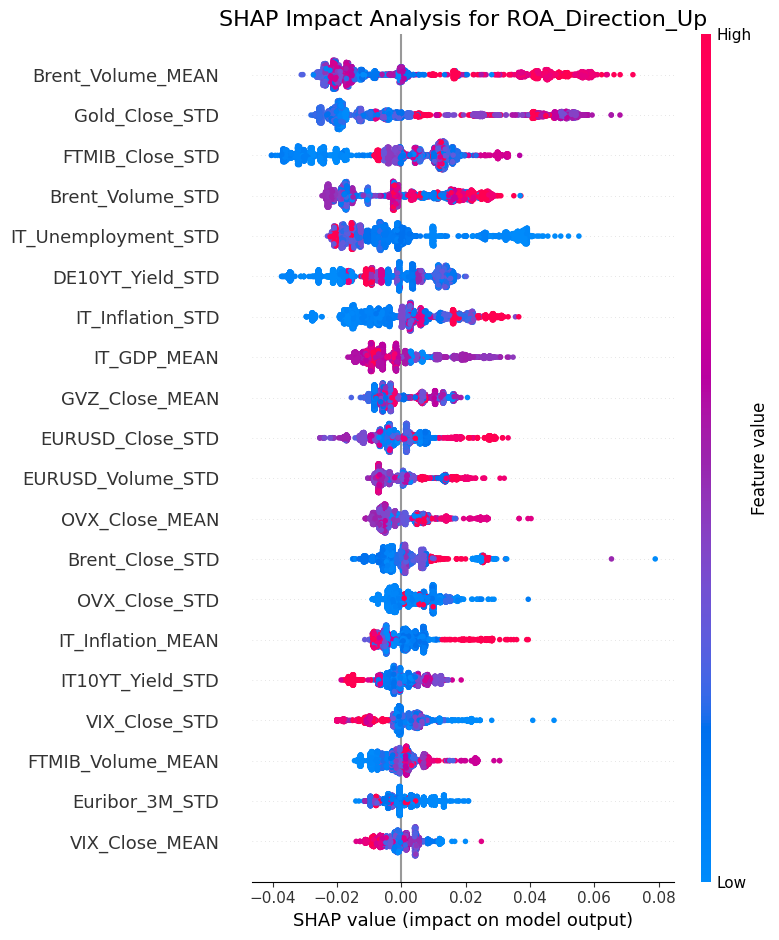


                       Net_Income_Direction_Up                        
Total valid 90-day windows extracted for classification: 4459

Top 10 Features by Mutual Information for Net_Income_Direction_Up:
           Feature  MI_Score
 EURUSD_Close_MEAN  0.189505
   Gold_Close_MEAN  0.188727
    OVX_Close_MEAN  0.187513
  IT10YT_Yield_STD  0.187414
    Euribor_3M_STD  0.187260
     VIX_Close_STD  0.186584
    VIX_Close_MEAN  0.186504
TTF_Gas_Close_MEAN  0.186089
 Brent_Volume_MEAN  0.184706
  FTMIB_Volume_STD  0.183627


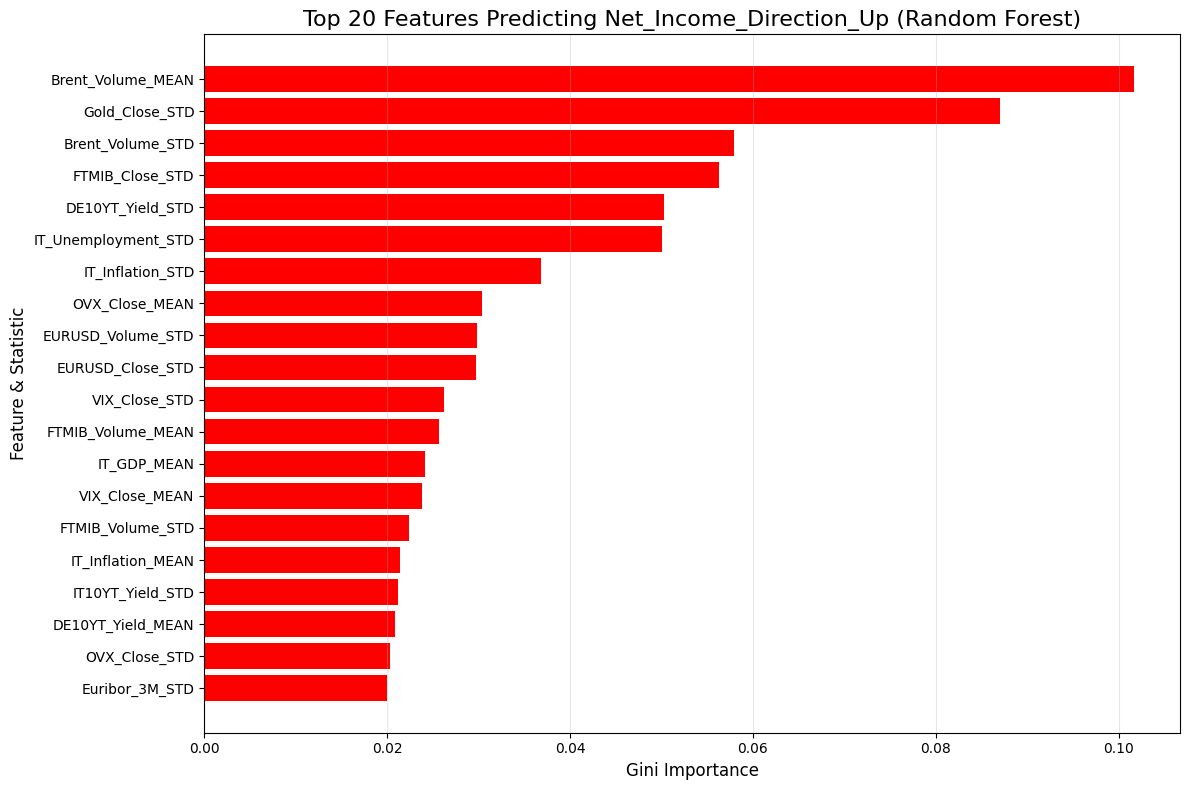

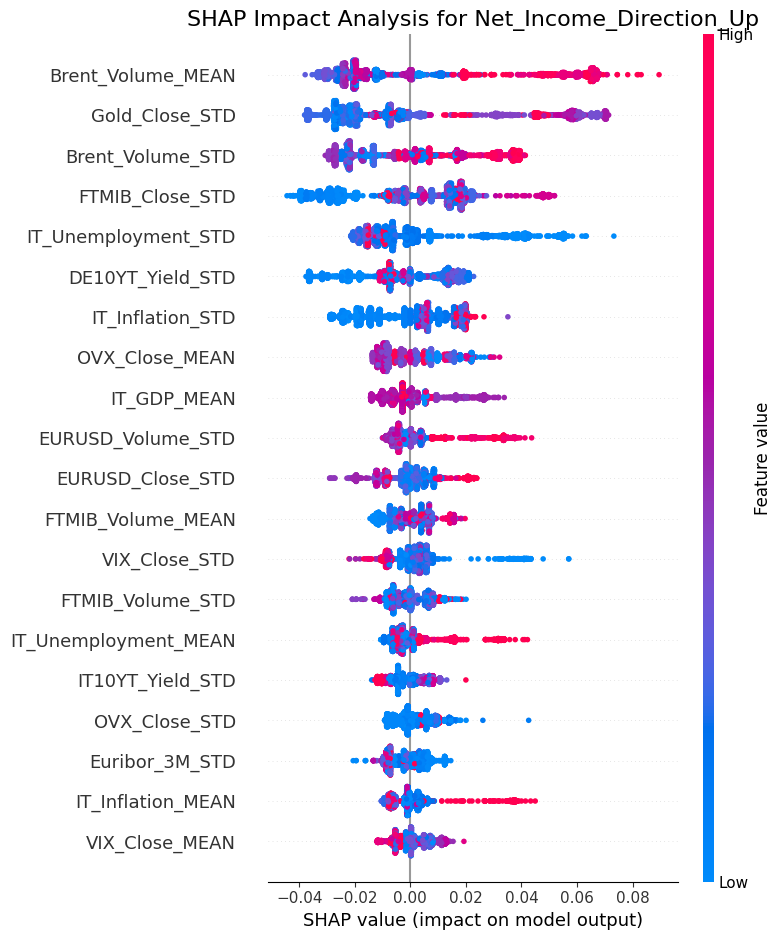

In [13]:
for target in directional_targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []
    target_indices = df[df[target].notna()].index

    for idx in target_indices:
        target_date = df.loc[idx, 'Date']
        company = df.loc[idx, 'Company']
        target_value = df.loc[idx, target]
        
        start_date = target_date - pd.Timedelta(days=90)
        
        window = df[(df['Company'] == company) & 
                    (df['Date'] > start_date) & 
                    (df['Date'] <= target_date)]
        
        if len(window) > 40:
            window_stats = {}
            for feat in features:
                window_stats[f"{feat}_MEAN"] = window[feat].mean()
                window_stats[f"{feat}_STD"] = window[feat].std()
                
            X_aggregated.append(window_stats)
            y_values.append(target_value)

    X_df = pd.DataFrame(X_aggregated).fillna(0)
    y_series = pd.Series(y_values)
    
    print(f"Total valid 90-day windows extracted for classification: {len(X_df)}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df)
    
    # Mutual Information
    mi_scores = mutual_info_classif(X_scaled, y_series, random_state=42)
    mi_df = pd.DataFrame({
        'Feature': X_df.columns,
        'MI_Score': mi_scores
    }).sort_values(by='MI_Score', ascending=False)
    
    print(f"\nTop 10 Features by Mutual Information for {target}:")
    print(mi_df.head(10).to_string(index=False))

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6)
    rf.fit(X_scaled, y_series)

    importance_df = pd.DataFrame({
        'Feature': X_df.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    # Plot Classification Random Forest
    top_features = importance_df.head(20).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 8))
    plt.barh(top_features['Feature'], top_features['Importance'], color='red')
    plt.title(f'Top 20 Features Predicting {target} (Random Forest)', fontsize=16)
    plt.xlabel('Gini Importance', fontsize=12)
    plt.ylabel('Feature & Statistic', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    
    rf_save_path = f'../Analysis/Features Importance/Momentum and Direction/{target}_RF.png'
    plt.savefig(rf_save_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Plot SHAP Values for Class 1 (UP)
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    
    # Isolate class 1 (up) to see what pushes the probability of a positive trend
    if isinstance(shap_values, list):
        shap_values_up = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values_up = shap_values[:, :, 1]
    else:
        shap_values_up = shap_values
        
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Impact Analysis for {target}", fontsize=16)
    shap.summary_plot(shap_values_up, X_df, plot_type="dot", show=False)
    plt.tight_layout()
    
    shap_save_path = f'../Analysis/Features Importance/Momentum and Direction/{target}_SHAP.png'
    plt.savefig(shap_save_path, dpi=300, bbox_inches='tight')
    plt.show()
